In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [2]:
#load cleaned dataset
df = pd.read_csv("../data/cleaned/agriculture_cleaned.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully
Shape: (16146, 80)


,dist_code,year,state_code,state_name,dist_name,rice_area_1000_ha,rice_production_1000_tons,rice_yield_kg_per_ha,wheat_area_1000_ha,wheat_production_1000_tons,...,sugarcane_yield_kg_per_ha,cotton_area_1000_ha,cotton_production_1000_tons,cotton_yield_kg_per_ha,fruits_area_1000_ha,vegetables_area_1000_ha,fruits_and_vegetables_area_1000_ha,potatoes_area_1000_ha,onion_area_1000_ha,fodder_area_1000_ha
0,1,1966,14,Chhattisgarh,Durg,548.0,185.0,337.59,44.0,20.0,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.0,409.0,747.71,50.0,26.0,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.3,468.0,841.27,53.7,30.0,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.4,400.8,711.40,49.4,26.5,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.6,473.6,828.55,44.2,29.0,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16146 entries, 0 to 16145
Data columns (total 80 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dist_code                                  16146 non-null  int64  
 1   year                                       16146 non-null  int64  
 2   state_code                                 16146 non-null  int64  
 3   state_name                                 16146 non-null  object 
 4   dist_name                                  16146 non-null  object 
 5   rice_area_1000_ha                          16146 non-null  float64
 6   rice_production_1000_tons                  16146 non-null  float64
 7   rice_yield_kg_per_ha                       16146 non-null  float64
 8   wheat_area_1000_ha                         16146 non-null  float64
 9   wheat_production_1000_tons                 16146 non-null  float64
 10  wheat_yield_kg_per_ha 

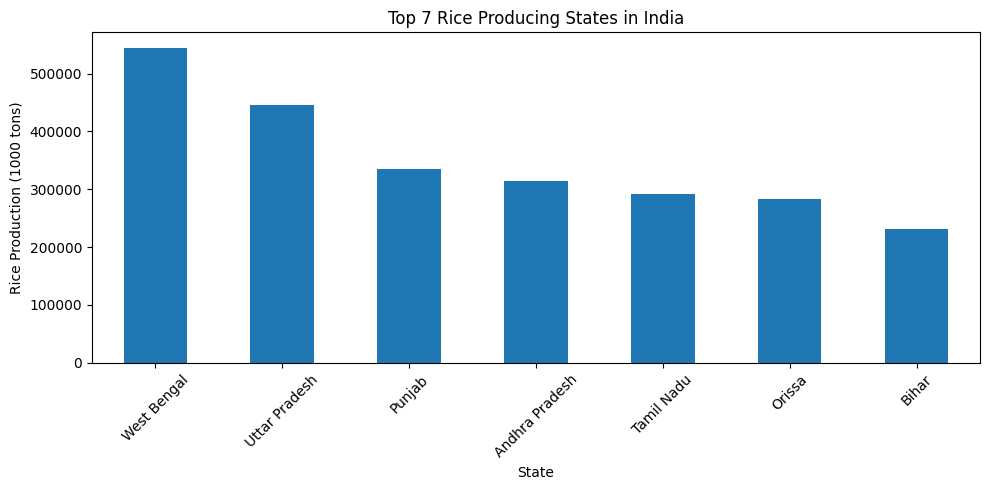

In [4]:
#cell4(rice producing states in india)
# Top 7 Rice Producing States
rice_state = (
    df.groupby("state_name")["rice_production_1000_tons"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
)

plt.figure(figsize=(10, 5))
rice_state.plot(kind="bar")
plt.title("Top 7 Rice Producing States in India")
plt.xlabel("State")
plt.ylabel("Rice Production (1000 tons)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
#### Insight
#The visualization indicates that rice production in India is concentrated in a few states, highlighting regional dominance in rice cultivation.


### Insight:
The visualization indicates that rice production in India is concentrated in a few states, highlighting regional dominance in rice cultivation.


In [7]:
#Cell 6: Prepare Wheat Data
# Top 5 Wheat Producing States
wheat_state = (
    df.groupby("state_name")["wheat_production_1000_tons"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

wheat_state


state_name
Uttar Pradesh     970210.07
Punjab            593848.90
Haryana           348429.60
Madhya Pradesh    338644.25
Rajasthan         265994.99
Name: wheat_production_1000_tons, dtype: float64

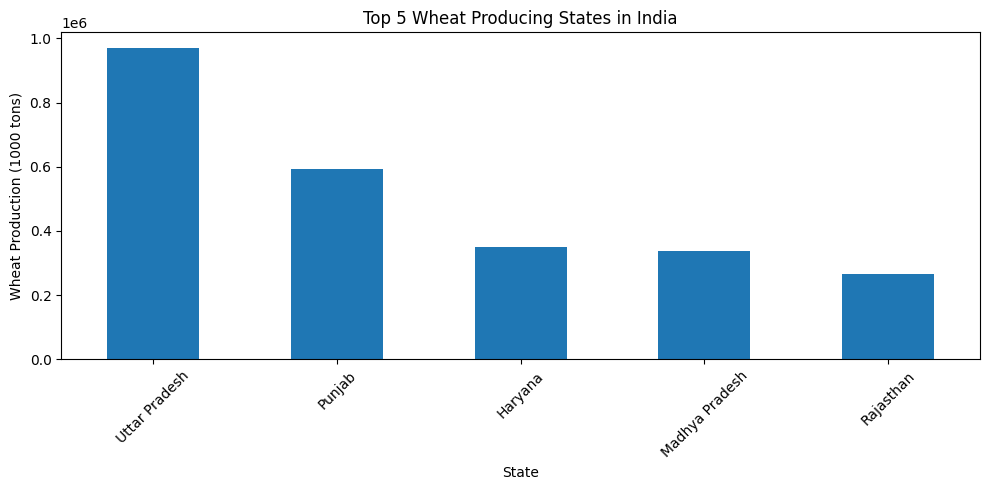

In [8]:
#Cell 7: Wheat Bar Chart
plt.figure(figsize=(10, 5))
wheat_state.plot(kind="bar")
plt.title("Top 5 Wheat Producing States in India")
plt.xlabel("State")
plt.ylabel("Wheat Production (1000 tons)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


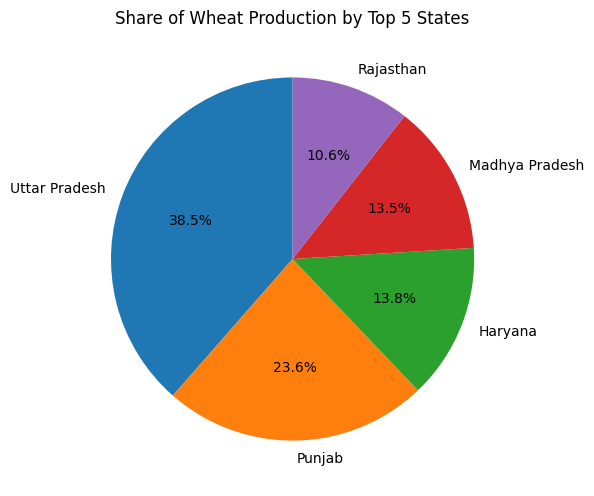

In [9]:
# 🔹 Cell 8: Wheat Pie Chart
plt.figure(figsize=(6, 6))
wheat_state.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Share of Wheat Production by Top 5 States")
plt.ylabel("")
plt.tight_layout()
plt.show()


### Insight:
The bar and pie charts show that wheat production is dominated by a small group of states, with the top producers contributing a significant share of national output.


In [10]:
#Cell 10: Select a Crop (Rice)
# Area vs Production for Rice
rice_area_prod = df[[
    "rice_area_1000_ha",
    "rice_production_1000_tons"
]].dropna()

rice_area_prod.head()

,rice_area_1000_ha,rice_production_1000_tons
0,548.0,185.0
1,547.0,409.0
2,556.3,468.0
3,563.4,400.8
4,571.6,473.6


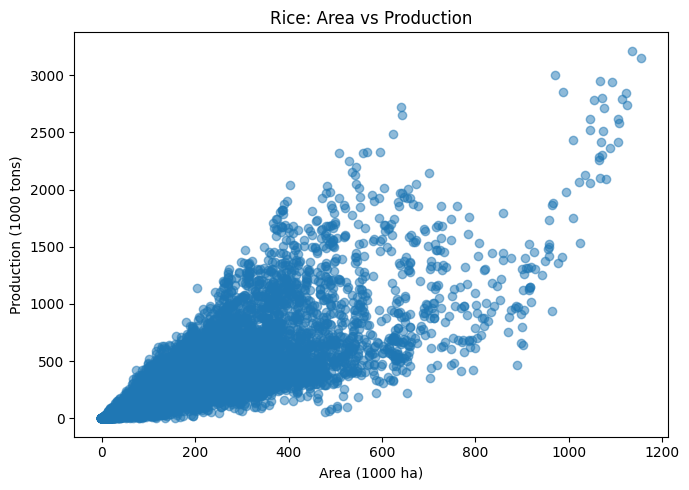

In [11]:
#Cell 11: Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(
    rice_area_prod["rice_area_1000_ha"],
    rice_area_prod["rice_production_1000_tons"],
    alpha=0.5
)
plt.title("Rice: Area vs Production")
plt.xlabel("Area (1000 ha)")
plt.ylabel("Production (1000 tons)")
plt.tight_layout()
plt.show()

In [12]:
correlation = rice_area_prod.corr().iloc[0, 1]
print("Correlation between Rice Area and Production:", round(correlation, 2))


Correlation between Rice Area and Production: 0.83


#### Insight:
The scatter plot and correlation value indicate a strong positive relationship between cultivated area and rice production, suggesting that expansion of cultivated land significantly influences output.


In [13]:
#STEP 3 – EDA (Plot 4)
#📉 Year-wise Production Trend (Line Chart)

#This shows:

#Growth / decline over time

#Agricultural development trends

#Long-term policy impact

#This is high-value insight for mentors.

In [14]:
#Cell 14: Year-wise Rice Production
# Year-wise Rice Production Trend
rice_year = (
    df.groupby("year")["rice_production_1000_tons"]
    .sum()
)

rice_year.head()

year
1966    29133.23
1967    35056.64
1968    34701.52
1969    35836.01
1970    39324.12
Name: rice_production_1000_tons, dtype: float64

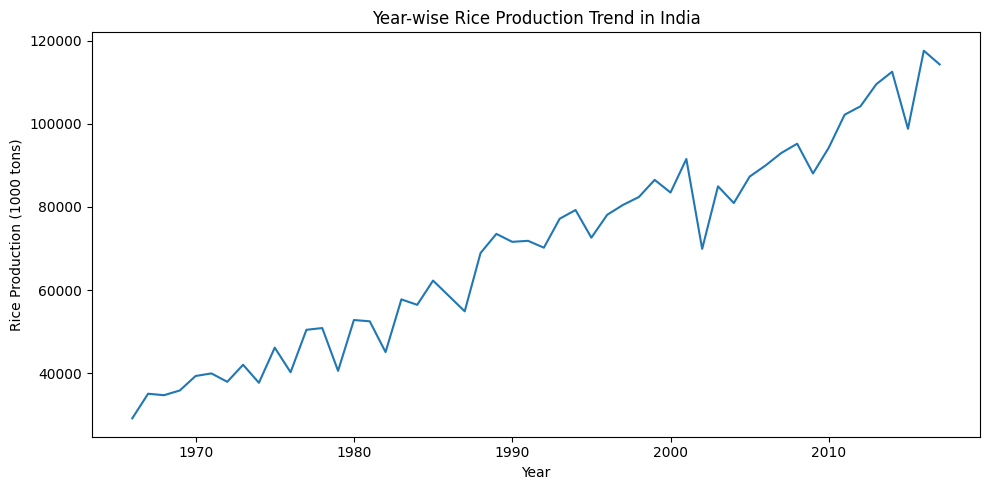

In [15]:
#Cell 15: Line Chart
plt.figure(figsize=(10, 5))
plt.plot(rice_year.index, rice_year.values)
plt.title("Year-wise Rice Production Trend in India")
plt.xlabel("Year")
plt.ylabel("Rice Production (1000 tons)")
plt.tight_layout()
plt.show()

### Insight:
The line chart shows a long-term increasing trend in rice production, reflecting improvements in agricultural practices, irrigation, and technology over the years.


In [16]:
#🧠 How to Explain STEP 3 in One Shot (Remember This)

#“I performed exploratory data analysis using the cleaned ICRISAT dataset to understand state-wise crop dominance, production concentration, area–production relationships, and long-term production trends. I supported insights with visualizations and documented key findings.”

#Perfect answer ✔️